# Importing

If you are a Mac user:

In [2]:
!pip apt-get install x11-utils

ERROR: unknown command "apt-get"


In [3]:
!sudo apt-get update
!sudo apt-get install -y x11-utils


Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [110 kB]
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [119 kB]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,626 B]
Hit:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:7 https://ppa.launchpadcontent.net/c2d4u.team/c2d4u4.0+/ubuntu jammy InRelease
Get:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [1,641 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,081 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-upd

In [4]:
pip install gym==0.22

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 631.1/631.1 kB 7.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for gym: filename=gym-0.22.0-py3-none-any.whl size=708363 sha256=6bd554c5ffe01a8dd52ed5517bfe3b9cd55242758813a917cc2eb16bdec26a0b
  Stored in directory: /root/.cache/pip/wheels/42/e8/e8/6dfbc92a1dcd76c1a5e2bb982750fd6b7e792239f46039e6b1
Successfully built gym
  Attempting uninstall: gym
    Found existing installation: gym 0.25.2
    Uninstalling gym-0.25.2:
      Successfully uninstalled gym-0.25.2


Whether you are a Windows or Mac user, you will need the following code blocks:

In [5]:
!pip install gym
!apt-get install python-opengl -y
!apt install xvfb -y

# Special gym environment
!pip install gym[atari]

# For rendering environment, you can use pyvirtualdisplay.
!pip install pyvirtualdisplay
!pip install piglet

# To activate virtual display
# need to run a script once for training an agent as follows
from pyvirtualdisplay import Display
display = Display(visible=0, size=(1400, 900))
display.start()

# This code creates a virtual display to draw game images on.
# If you are running locally, just ignore it
import os
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY"))==0:
    !bash ../xvfb start
    %env DISPLAY=:1

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
E: Unable to locate package python-opengl
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libxfont2 x11-xkb-utils xfonts-base xfonts-encodings xfonts-utils xserver-common
The following NEW packages will be installed:
  libxfont2 x11-xkb-utils xfonts-base xfonts-encodings xfonts-utils xserver-common xvfb
0 upgraded, 7 newly installed, 0 to remove and 45 not upgraded.
Need to get 7,729 kB of archives.
After this operation, 11.7 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libxfont2 amd64 1:2.0.5-1build1 [94.5 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 x11-xkb-utils amd64 7.7+5build4 [172 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/main amd64 xfonts-encodings all 1:1.0.5-0ubuntu2 [578 kB]
Get:4 http://archive.ubuntu.c

In [6]:
#
# Import libraries
#
import gym
from gym import logger as gymlogger
from gym.wrappers import Monitor
gymlogger.set_level(40) # error only
#import tensorflow as tf
import numpy as np
import random
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
import math
import glob
import io
import base64
from IPython.display import HTML

from IPython import display as ipythondisplay

"""
Utility functions to enable video recording of gym environment and displaying it
To enable video, just do "env = wrap_env(env)""
"""

def show_video():
  mp4list = glob.glob('video/*.mp4')
  if len(mp4list) > 0:
    mp4 = mp4list[0]
    video = io.open(mp4, 'r+b').read()
    encoded = base64.b64encode(video)
    ipythondisplay.display(HTML(data='''<video alt="test" autoplay
                loop controls style="height: 400px;">
                <source src="data:video/mp4;base64,{0}" type="video/mp4" />
             </video>'''.format(encoded.decode('ascii'))))
  else:
    print("Could not find video")


def wrap_env(env):
  env = Monitor(env, './video', force=True)
  return env

# Problem 1

Episode: 100
Episode: 200
Episode: 300
Episode: 400
Episode: 500
Episode: 600
Episode: 700
Episode: 800
Episode: 900
Episode: 1000
Episode: 1100
Episode: 1200
Episode: 1300
Episode: 1400
Episode: 1500
Episode: 1600
Episode: 1700
Episode: 1800
Episode: 1900
Episode: 2000
Training finished.



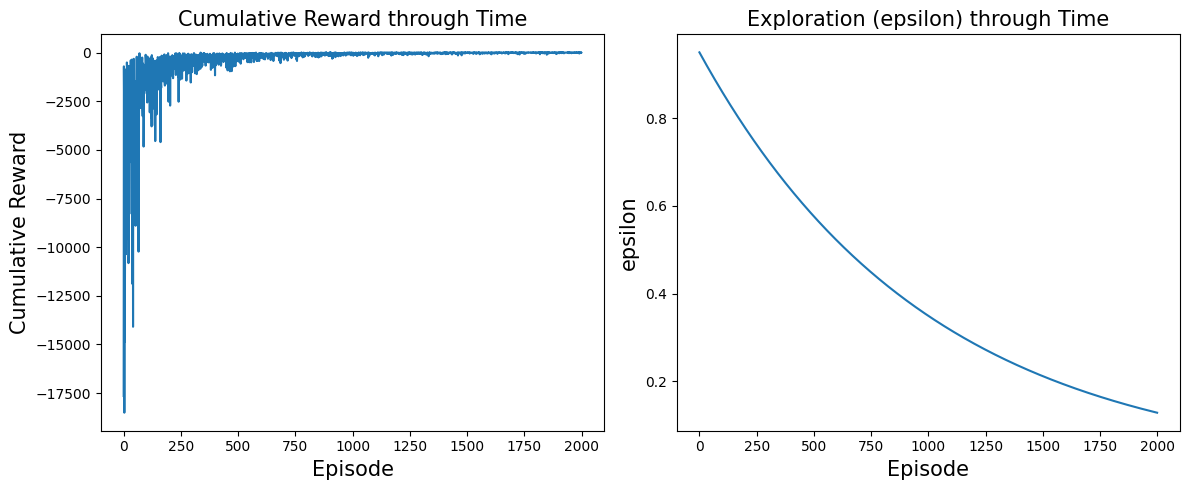

In [12]:
import numpy as np
import gym
import matplotlib.pyplot as plt

# Specify which environment to use.
env = gym.make("Taxi-v3").env
env.reset()

# Initialize table of Q-values
q_table = np.zeros([env.observation_space.n, env.action_space.n])

# Initialize RL parameters
max_num_episodes = 2000
epsilon = 0.95  # Starting value of epsilon
epsilon_min = 0.01  # Minimum value of epsilon
epsilon_decay = 0.999  # Decay multiplicative factor for epsilon
alpha = 0.1  # Learning rate
gamma = 0.6  # Discount factor

# For plotting metrics
cumulative_reward_each_episode = []
epsilon_each_episode = []

for episode in range(max_num_episodes):
    state = env.reset()
    cumulative_reward = 0
    done = False

    while not done:
        # Epsilon-greedy action selection
        if np.random.rand() < epsilon:
            action = env.action_space.sample()  # Exploration: random action
        else:
            action = np.argmax(q_table[state, :])  # Exploitation: best action from Q-table

        # Take action and observe reward and new state
        next_state, reward, done, info = env.step(action)
        cumulative_reward += reward

        # Q-learning update
        old_value = q_table[state, action]
        next_max = np.max(q_table[next_state])
        new_value = (1 - alpha) * old_value + alpha * (reward + gamma * next_max)
        q_table[state, action] = new_value
        state = next_state

    # Append total episode reward and decay epsilon
    cumulative_reward_each_episode.append(cumulative_reward)
    epsilon_each_episode.append(epsilon)
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    # Print episode information every 100 episodes
    if (episode + 1) % 100 == 0:
        print(f'Episode: {episode + 1}')

print("Training finished.\n")

# Plot the Cumulative Reward and Epsilon value through time.
fsize = 15
plt.figure(figsize=(12, 5))

# Cumulative Reward plot
plt.subplot(1, 2, 1)
plt.plot(cumulative_reward_each_episode)
plt.title('Cumulative Reward through Time', fontsize=fsize)
plt.xlabel('Episode', fontsize=fsize)
plt.ylabel('Cumulative Reward', fontsize=fsize)

# Epsilon plot
plt.subplot(1, 2, 2)
plt.plot(epsilon_each_episode)
plt.title('Exploration (epsilon) through Time', fontsize=fsize)
plt.xlabel('Episode', fontsize=fsize)
plt.ylabel('epsilon', fontsize=fsize)

plt.tight_layout()
plt.show()


In [13]:
# Once training is finished, run through one more episode using exploitation only.
done = False
state = env.reset()

while not done:
    env.render()

    ##########################################
    # Choose an action based on exploitation.
    ##########################################
    action = np.argmax(q_table[state, :])  # Choose the best action based on the trained Q-table
    state, reward, done, info = env.step(action)

    if done:
        break

env.close()


+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (South)
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (West)
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (West)
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (South)
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (South)
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (Pickup)
+---------+
|R: | : :G|
| : | : : |
| : : : : |
|_| : | : |
|Y| : |B: |
+---------+
  (North)
+---------+
|R: | : :G|
| : | : : |
|_: : : : |
| | : | : |
|Y| : |B: |
+---------+
  (North)
+---------+
|R: | : :G|
| : | : : |
| :_: : : |
| | : | : |
|Y| : |B: |
+---------+
  (East)
+---------+
|R: | : :G|
| : | : : |
| : :_: : |
| | : | : |
|Y| : |B: |

# Problem 2

In [14]:
# I have included code to help you discretize the state space.
# You DO NOT need to keep these specific bin ranges.
# In fact, you may not want to keep these bin ranges.
# I have provided this code to make it easier for you to modify and to save
# you time.
# You can alter or discretize the state space however you wish.
# You do not need to keep all 4 state features if you have an argument for
# eliminating features.

import pandas as pd

# Discretize input state to make Q-table and to reduce dimensionality
def discretize(state):

  #print ( state )

  # First, set up arrays of the left bin edges
  # Note: your bin sizes do not need to be of uniform width.
  bins_pos = [-4.8, -1, 1, 4.8]
  bins_vel = [-3.4*10**38, -5, 5, 3.4*10**38 ]
  bins_w = [-3.4*10**38, -100, -50, -40, -30, -20, -10, -5, -2, 0, 2, 5, 10, 20, 30, 40, 50, 100, 3.4*10**38]

  angle_range = 0.43*2
  num_angle_bins = 12
  angle_bin_stepsize = angle_range / num_angle_bins
  bins_ang = [-0.43]
  for i in range(1, num_angle_bins):
    bins_ang.append( bins_ang[i-1]+ angle_bin_stepsize )

  cart_position_bin = pd.cut([state[0]], bins=bins_pos, include_lowest=True)
  cart_velocity_bin = pd.cut([state[1]], bins=bins_vel, include_lowest=True)
  pole_angle_bin    = pd.cut([state[2]], bins=bins_ang, include_lowest=True)
  angle_rate_bin    = pd.cut([state[3]], bins=bins_w  , include_lowest=True)

  # To verify the order of the state variables:
  #   https://github.com/openai/gym/blob/master/gym/envs/classic_control/cartpole.py

  return [cart_position_bin[0].left, cart_velocity_bin[0].left, pole_angle_bin[0].left, angle_rate_bin[0].left]


In [15]:
# Simple code to test your discretization.

# Specify which environment to use.
env = gym.make('CartPole-v0')
state = env.reset()

action = env.action_space.sample() # Explore action space
state, reward, done, info = env.step(action)
print ( 'Continuous state: ')
print ( state )

discretized_state = discretize(state)
print ( 'Discretized state: ')
print ( discretized_state )

env.close()


Continuous state: 
[ 0.02974109  0.20435704  0.04858732 -0.2892414 ]
Discretized state: 
[-1.0, -5.0, -2.78e-17, -2.0]


In [ ]:
# Specify which environment to use.
env = gym.make('CartPole-v0')
#env = wrap_env(env)
state = env.reset()

##########################################
# Initialize your Q-values.
# Note: you may use whichever data structure you wish.
#       I used a dictionary, but a list works, too.
##########################################



##########################################
# Initialize RL Parameters
##########################################



# For plotting metrics
cumulative_reward_each_episode = []
epsilon_each_episode = []


# To start off wish debugging your code, use 1 episode. Increase this once
# your code starts to work.
maxNumEpisodes = 1

# For each episode
for i in range(maxNumEpisodes):

  # Reset to initial conditions
  state = env.reset()

  ##########################################
  # Discretize the state
  # Note: you'll need to modify the discretize function
  #       provided above.
  ##########################################
  state = discretize(state)

	# At the beginning of each episode, set the cumulative reward variable to zero.
  cumulative_reward = 0
  done = False

  # For every step in the episode
  while not done:
    #env.render()

    ##########################################
    # For every time step, using epsilon-greedy to choose between
    # exploration and exploitation.
    # Implement epsilon-greedy exploration.
    # Hint: to return a random action, do this:
    #           action = env.action_space.sample()
    ##########################################



		# Take the action.
		# This moves the agent to a new state and earns a reward
    next_state, reward, done, info = env.step(action)

    # Discrete the state
    next_state = discretize(next_state)

    # Add the reward just earned to the cumulative reward variable
    cumulative_reward += reward

		##########################################
    # Update your estimate of Q(s,a)
    ##########################################



    state = next_state

    # If the episode is finished, do a few things.
    if done:
      # Save the cumulative reward from the previous episode to an array.
      cumulative_reward_each_episode.append(cumulative_reward)

      # Save the epsilon used in this episode.
      epsilon_each_episode.append(epsilon)

      ##########################################
      # Decay epsilon.
      # If you want to decay or change the value of epsilon at the end of
      # each episode, do so here.
      ##########################################


  if i % 100 == 0:
    print('Episode: {0}'.format(i))

env.close()
#show_video()
print("Training finished.\n")


# Plot the Cumulative Reward and Epsilon value through time.
fsize = 15

plt.plot(cumulative_reward_each_episode)
plt.title('Cumulative Reward through Time', fontsize=fsize)
plt.xlabel('Episode', fontsize=fsize)
plt.ylabel('Cumulative Reward', fontsize=fsize)
plt.show()

plt.plot(epsilon_each_episode)
plt.title('Exploration (epsilon) through Time', fontsize=fsize)
plt.xlabel('Episode', fontsize=fsize)
plt.ylabel('epsilon', fontsize=fsize)
plt.show()

Episode: 0, Reward: 33.0, Epsilon: 0.995
Episode: 100, Reward: 11.0, Epsilon: 0.6027415843082742
Episode: 200, Reward: 13.0, Epsilon: 0.36512303261753626
Episode: 300, Reward: 12.0, Epsilon: 0.2211807388415433
Episode: 400, Reward: 12.0, Epsilon: 0.13398475271138335
Episode: 500, Reward: 12.0, Epsilon: 0.0811640021330769
Episode: 600, Reward: 12.0, Epsilon: 0.04916675299948831
Episode: 700, Reward: 12.0, Epsilon: 0.029783765425331846
Episode: 800, Reward: 14.0, Epsilon: 0.018042124582040707
Episode: 900, Reward: 15.0, Epsilon: 0.010929385683282892
Episode: 1000, Reward: 14.0, Epsilon: 0.01
Episode: 1100, Reward: 16.0, Epsilon: 0.01
Episode: 1200, Reward: 13.0, Epsilon: 0.01
Episode: 1300, Reward: 13.0, Epsilon: 0.01
Episode: 1400, Reward: 15.0, Epsilon: 0.01
Episode: 1500, Reward: 14.0, Epsilon: 0.01
Episode: 1600, Reward: 13.0, Epsilon: 0.01
Episode: 1700, Reward: 12.0, Epsilon: 0.01
Episode: 1800, Reward: 14.0, Epsilon: 0.01
Episode: 1900, Reward: 11.0, Epsilon: 0.01


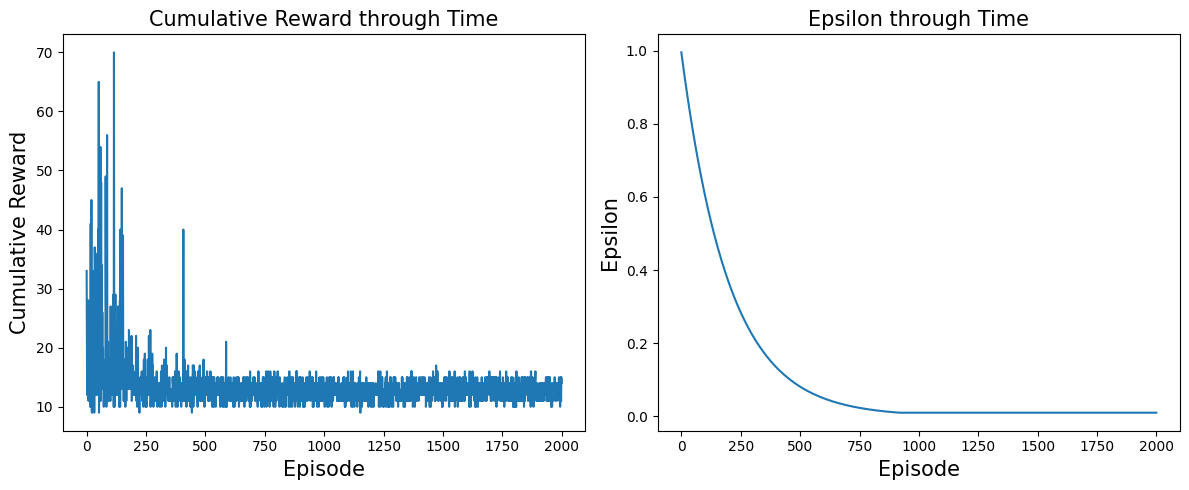

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import gym

# Initialize the Gym environment
env = gym.make('CartPole-v0')
state = env.reset()

# Discretize input state function from previous context
def discretize(state):
    bins_pos = [-2.4, -0.8, 0.8, 2.4]
    bins_vel = [-3.0, -1, 1, 3.0]
    bins_ang = [-0.5, -0.25, 0.25, 0.5]
    bins_ang_vel = [-3.5, -1, 1, 3.5]
    digitized = [
        np.digitize(state[0], bins_pos),
        np.digitize(state[1], bins_vel),
        np.digitize(state[2], bins_ang),
        np.digitize(state[3], bins_ang_vel)
    ]
    return sum([x * (len(bins_pos) ** i) for i, x in enumerate(digitized)])

# Initialize Q-values and other parameters
Q = {}
alpha = 0.1
gamma = 0.99
epsilon = 1.0
epsilon_decay = 0.995
min_epsilon = 0.01

cumulative_reward_each_episode = []
epsilon_each_episode = []

maxNumEpisodes = 2000

for i in range(maxNumEpisodes):
    state = discretize(env.reset())
    cumulative_reward = 0
    done = False

    while not done:
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q.get(state, np.zeros(env.action_space.n)))

        next_state, reward, done, info = env.step(action)
        next_state = discretize(next_state)

        old_value = Q.get(state, np.zeros(env.action_space.n))[action]
        next_max = np.max(Q.get(next_state, np.zeros(env.action_space.n)))

        new_value = (1 - alpha) * old_value + alpha * (reward + gamma * next_max)
        Q[state] = Q.get(state, np.zeros(env.action_space.n))
        Q[state][action] = new_value

        state = next_state
        cumulative_reward += reward

    cumulative_reward_each_episode.append(cumulative_reward)
    epsilon = max(min_epsilon, epsilon * epsilon_decay)
    epsilon_each_episode.append(epsilon)

    if i % 100 == 0:
        print(f'Episode: {i}, Reward: {cumulative_reward}, Epsilon: {epsilon}')

env.close()

# Plotting
fsize = 15
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cumulative_reward_each_episode)
plt.title('Cumulative Reward through Time', fontsize=fsize)
plt.xlabel('Episode', fontsize=fsize)
plt.ylabel('Cumulative Reward', fontsize=fsize)

plt.subplot(1, 2, 2)
plt.plot(epsilon_each_episode)
plt.title('Epsilon through Time', fontsize=fsize)
plt.xlabel('Episode', fontsize=fsize)
plt.ylabel('Epsilon', fontsize=fsize)
plt.tight_layout()
plt.show()


Episode: 1, Total Reward: 20.0
Episode: 101, Total Reward: 18.0
Episode: 201, Total Reward: 10.0
Episode: 301, Total Reward: 47.0
Episode: 401, Total Reward: 59.0
Episode: 501, Total Reward: 35.0
Episode: 601, Total Reward: 11.0
Episode: 701, Total Reward: 36.0
Episode: 801, Total Reward: 34.0
Episode: 901, Total Reward: 35.0
Episode: 1001, Total Reward: 35.0
Episode: 1101, Total Reward: 53.0
Episode: 1201, Total Reward: 26.0
Episode: 1301, Total Reward: 52.0
Episode: 1401, Total Reward: 56.0
Episode: 1501, Total Reward: 35.0
Episode: 1601, Total Reward: 52.0
Episode: 1701, Total Reward: 31.0
Episode: 1801, Total Reward: 68.0
Episode: 1901, Total Reward: 31.0
Training finished.



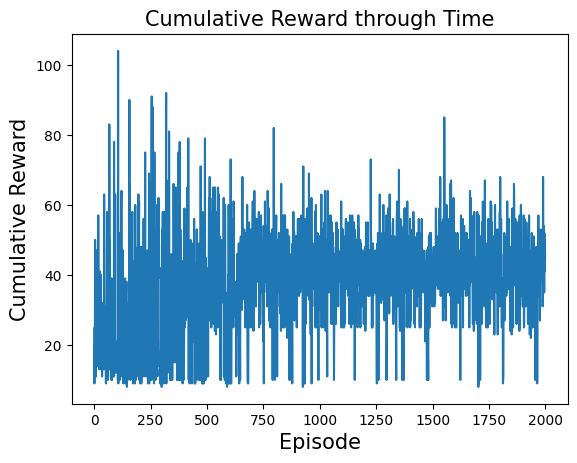

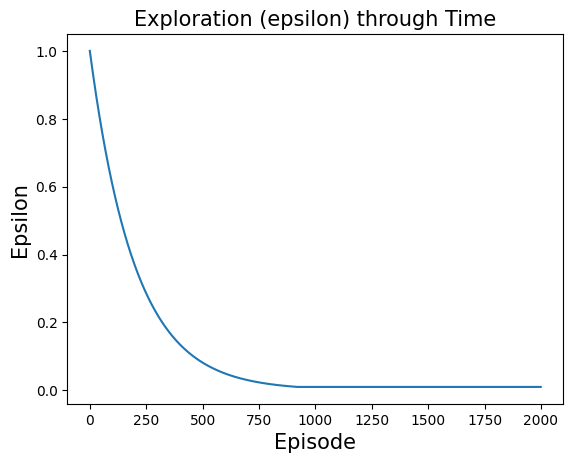

In [44]:
env = gym.make('CartPole-v0')
state = env.reset()

# Initialize Q-values
n_bins = (4, 4, 12, 19)  # Based on the discretization
q_table = np.zeros(n_bins + (env.action_space.n,))

# Initialize RL Parameters
learning_rate = 0.1
discount_factor = 0.99
epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.995

# For plotting metrics
cumulative_reward_each_episode = []
epsilon_each_episode = []

# To start off with debugging your code, use 1 episode. Increase this once your code starts to work.
maxNumEpisodes = 2000

for i in range(maxNumEpisodes):
    state = env.reset()
    state = discretize(state)
    cumulative_reward = 0
    done = False

    while not done:
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        next_state, reward, done, info = env.step(action)
        next_state = discretize(next_state)

        # Update Q-values
        q_next = np.max(q_table[next_state])
        q_table[state + (action,)] += learning_rate * (reward + discount_factor * q_next - q_table[state + (action,)])
        state = next_state
        cumulative_reward += reward

    cumulative_reward_each_episode.append(cumulative_reward)
    epsilon_each_episode.append(epsilon)
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    if i % 100 == 0:
        print(f'Episode: {i+1}, Total Reward: {cumulative_reward}')

env.close()
print("Training finished.\n")

# Plotting the results
fsize = 15
plt.plot(cumulative_reward_each_episode)
plt.title('Cumulative Reward through Time', fontsize=fsize)
plt.xlabel('Episode', fontsize=fsize)
plt.ylabel('Cumulative Reward', fontsize=fsize)
plt.show()

plt.plot(epsilon_each_episode)
plt.title('Exploration (epsilon) through Time', fontsize=fsize)
plt.xlabel('Episode', fontsize=fsize)
plt.ylabel('Epsilon', fontsize=fsize)
plt.show()

In [ ]:
# Once training is finished, run through one more episode using exploitation only.

